# 8.1 导读与数学基础：生成式推荐

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

在进入 OpenOneRec 与 HSTU 前，理解 token、Semantic ID、自回归概率、交叉熵、因果 mask、约束解码与列表指标。

## Setup

本 Notebook 的默认真实数据是 **KuaiRand-Pure：真实短视频曝光、点击、长播与多反馈序列**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。 **生成式章节默认要求 CUDA；无 CUDA 时只允许自动化测试执行 CPU basic smoke，不进行完整精度验证。**

**主要资料：** [TIGER](https://arxiv.org/abs/2305.05065) · [OpenOneRec](https://github.com/Kuaishou-OneRec/OpenOneRec) · [HSTU](https://arxiv.org/abs/2402.17152)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "kuairand"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'kuairand', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 如何使用本导读

先阅读布局和论文问题，再运行共同数学演示。完成 Checks 后进入独立算法 Notebook；各算法会重新给出本模型的公式和更小的 Python 演示，不要求记住本页所有公式。

## 本章布局与选型地图

| 子章节 | 输出对象 | 核心数学 | 系统难点 |
|---|---|---|---|
| 8.2 OpenOneRec | Semantic ID / 推荐列表 | 自回归、trie、偏好优化 | 合法性、重复、解码 P99 |
| 8.3 DLRM HSTU | 下一 item / 行为序列 | 因果序列建模、交叉熵 | 长序列吞吐与状态缓存 |
| 8.4 总结 | 两个实验结果 | 指标方向与 ROI | 不同任务不能只看单一分数 |

生成式召回生成 item 标识；生成式排序输出分数、标签或排列；召排融合直接生成列表/session。三者的输入、输出和成本并不相同。

## 来源论文与工业路径

- **TIGER (2023)** 用 RQ-VAE 将 item 表示成多级 Semantic ID，再把全库召回转为受约束生成。
- **HSTU (2024)** 针对高基数、非平稳行为流设计序列模型与系统协同。
- **OpenOneRec** 公开列表生成、奖励模型、偏好优化和 RecIF-Bench 流程。

生成式方案不是把 LLM API 接到推荐器上。目录合法性、增量更新、重复控制、缓存、吞吐和 GPU ROI 都是模型定义的一部分。

## 共同数学：自回归概率、因果性与 NDCG

序列概率分解为

$$P(y_1,\ldots,y_T|x)=\prod_{t=1}^TP(y_t|y_{<t},x)$$

训练用 teacher forcing：第 $t$ 步输入真实前缀，最小化下一 token 的交叉熵。推理时输入自己已生成的前缀，因此错误可能累积。

因果 mask 让当前位置只能看过去；目录 trie 只保留合法后继。列表质量常用
$\mathrm{DCG@K}=\sum_{r=1}^K rel_r/\log_2(r+1)$，再除以理想 DCG 得 NDCG。越相关的 item 越靠前，分数越高。

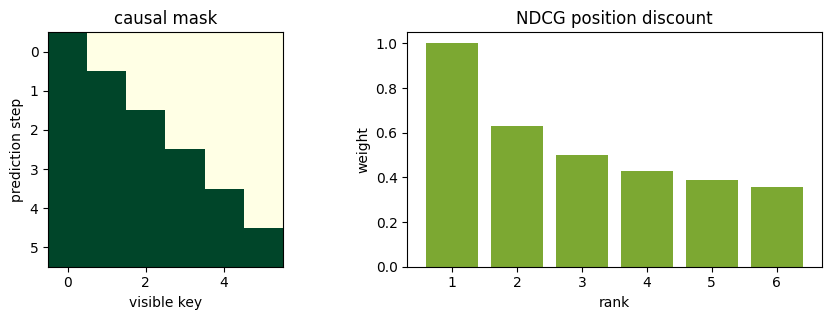

{'prefix': (1, 2), 'allowed_next_tokens': [3, 4]}


In [2]:
import numpy as np, matplotlib.pyplot as plt
length=6; causal=np.tril(np.ones((length,length)))
fig,axes=plt.subplots(1,2,figsize=(9,3.3))
axes[0].imshow(causal,cmap='YlGn',vmin=0,vmax=1); axes[0].set(title='causal mask',xlabel='visible key',ylabel='prediction step')
ranks=np.arange(1,7); discount=1/np.log2(ranks+1); axes[1].bar(ranks,discount,color='#7ca832'); axes[1].set(title='NDCG position discount',xlabel='rank',ylabel='weight')
plt.tight_layout(); plt.show()
catalog={(1,2,3),(1,2,4),(2,1,5)}; prefix=(1,2)
allowed=sorted({code[len(prefix)] for code in catalog if code[:len(prefix)]==prefix})
print({'prefix':prefix,'allowed_next_tokens':allowed})

## 学习顺序

1. 说清业务阶段和输入输出；2. 手算共享数学；3. 进入每个独立算法；4. 执行训练与推理；5. 最后打开章节总结读取实际结果。

## Checks

In [3]:
relevant={3,4}; ranked=[3,8,4]
dcg=sum((item in relevant)/np.log2(rank+2) for rank,item in enumerate(ranked))
ideal=sum(1/np.log2(rank+2) for rank in range(len(relevant)))
ndcg=dcg/ideal
assert allowed==[3,4] and 0<=ndcg<=1
print({'NDCG@3':round(float(ndcg),3),'trie_constraint':'PASS'})

{'NDCG@3': 0.92, 'trie_constraint': 'PASS'}


## Next Steps

从左侧 Notebook 导航进入本章第一个算法。遇到公式时依次检查：符号代表什么、数组形状是什么、用小数字怎么算、代码输出是否符合直觉。